In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns
import random
from ISLP.models import (ModelSpec as MS, 
                         summarize)
from utils.linear_reg_fun import linear_regresion_per_state
import statsmodels.api as sm

c:\Users\morit\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
random.seed(1234)

fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)

#fashion_df = fashion_df.fillna(0)

grocery_df = pd.read_csv("./data/grocery_data.csv")
grocery_df["Order Date"] = pd.to_datetime(grocery_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
grocery_df.set_index("Order Date", inplace=True)
grocery_df.drop(columns=["Unnamed: 0"], inplace=True)

In [3]:
# Filter for one state 
# Arrange by date 
# Calc temp - temp(t=-365)
# Calc first oder difference in revenue
# for each state filter out days which were only used to calc temp-365 / meaning the day bevore revenue was recorded

## Manual preprocessing for only one state (CA)

All of the preprocessing steps are also included in the linear_reg_fun function to be performed for multiple states at the same time. 

In [4]:
df_one_state_filter = fashion_df["Shipping Address State"] == "CA"
df_one_state = fashion_df[df_one_state_filter].copy()

### Create 365 day laged temperature column

In [5]:
df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)

### Create 365 laged rain column

In [6]:
df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)
df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)

### Create first order diff for Revenue

In [7]:
first_order_diff = [0]

for j in range(1,len(df_one_state)): 
    first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])

df_one_state["first_order_diff_Revenue"] = first_order_diff
df_one_state["first_order_diff_Revenue"] = df_one_state["first_order_diff_Revenue"].round(4)

C:\Users\morit\AppData\Local\Temp\ipykernel_25976\120880988.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])


### Lag first order diff for Revenue by 1 day

From testing with the autocorrelation we know that lagging the first order diff of revenue by 1 day is the best fit for our data    

In [8]:
df_one_state.loc[:, "first_order_diff_Revenue_lagged"] = df_one_state["first_order_diff_Revenue"].shift(-1)

### Create a SMA 7 for Hot, Cold, Rain Clothing

In [9]:
df_one_state.loc[:, "SMA7_ratio_hot_weather_clothing"] = df_one_state["ratio_hot_weather"].rolling(7).mean().round(2)

df_one_state.loc[:, "SMA7_ratio_cold_weather_clothing"] = df_one_state["ratio_cold_weather"].rolling(7).mean().round(2)

df_one_state.loc[:, "SMA7_ratio_rain_weather_clothing"] = df_one_state["ratio_rain_protection"].rolling(7).mean().round(2)

### Remove days wich were only used for temp calculations

In [10]:
df_one_state = df_one_state.iloc[365:, :]

### Create linear time counter column

In [11]:
df_one_state.loc[:, 'Time'] = np.arange(len(df_one_state))
df_one_state = df_one_state.fillna(0)

In [21]:
df_one_state.head()

,Shipping Address State,Revenue,Survey ResponseID,weather_category,ratio_cold_weather,ratio_fashion_accessories,ratio_hot_weather,ratio_indoor_basic,ratio_other,ratio_rain_protection,...,tmin,tavg,Temp_No_Season,Rain_No_Season,first_order_diff_Revenue,first_order_diff_Revenue_lagged,SMA7_ratio_hot_weather_clothing,SMA7_ratio_cold_weather_clothing,SMA7_ratio_rain_weather_clothing,Time
Order Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,CA,54.68,"['R_3HNOpheZEt8babI', 'R_1pKZVLBbrpZM8bP', 'R_...","['hot_weather', 'indoor_basic', 'fashion_acces...",0.0000,0.2376,0.1041,0.6584,0.0,0.0000,...,3.878,10.109,5.261,-3.757,54.68,158.96,0.0,0.0,0.0,0
2018-01-02,CA,213.64,"['R_3rHSccsh0mlkeuy', 'R_2taM3mpNPF0o1yf', 'R_...","['cold_weather', 'rain_protection', 'indoor_ba...",0.2433,0.1051,0.0000,0.4129,0.0,0.2387,...,3.808,10.675,6.692,-1.864,158.96,-181.66,0.0,0.0,0.0,1
2018-01-03,CA,31.98,"['R_1hLPyY3aamfi3xT', 'R_yRaAO89bhwJb9xD']",['indoor_basic'],0.0000,0.0000,0.0000,1.0000,0.0,0.0000,...,5.446,11.208,7.919,-4.210,-181.66,26.41,0.0,0.0,0.0,2
2018-01-04,CA,58.39,"['R_2QXq900Df6biUD7', 'R_cCucjmijTJETC6d', 'R_...","['cold_weather', 'fashion_accessories']",0.5722,0.4278,0.0000,0.0000,0.0,0.0000,...,5.409,10.694,5.531,-17.367,26.41,28.27,0.0,0.0,0.0,3
2018-01-05,CA,86.66,['R_2r7Zl5CTeW1dMqd'],['indoor_basic'],0.0000,0.0000,0.0000,1.0000,0.0,0.0000,...,6.662,11.527,5.609,-10.700,28.27,-42.68,0.0,0.0,0.0,4


# Linear Regressions

### Linear Regression: first order diff Revenue ~ Temp no Season

In [22]:
# Only for California
x = MS(["Temp_No_Season"]).fit_transform(df_one_state)
y = df_one_state["first_order_diff_Revenue"]
model = sm.OLS(y, sm.add_constant(x))
results = model.fit()

print(results.summary())

# For each state
Lin_reg_Rev_Temp_no_Season_fashion= linear_regresion_per_state(fashion_df, y_input="first_order_diff_Revenue", X_input=["Temp_No_Season"])

plt.scatter(df_one_state.first_order_diff_Revenue, df_one_state.Temp_No_Season)

                               OLS Regression Results                               
Dep. Variable:     first_order_diff_Revenue   R-squared:                       0.000
Model:                                  OLS   Adj. R-squared:                 -0.001
Method:                       Least Squares   F-statistic:                  0.009600
Date:                      Wed, 05 Feb 2025   Prob (F-statistic):              0.922
Time:                              17:13:05   Log-Likelihood:                -12670.
No. Observations:                      1905   AIC:                         2.534e+04
Df Residuals:                          1903   BIC:                         2.536e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

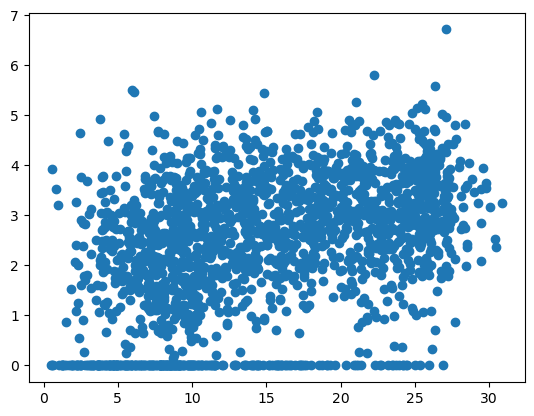

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     386.9
Date:                Wed, 05 Feb 2025   Prob (F-statistic):           1.44e-78
Time:                        17:26:25   Log-Likelihood:                -3116.6
No. Observations:                1905   AIC:                             6237.
Df Residuals:                    1903   BIC:                             6248.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.2851      0.064     20.115      0.0

In [40]:
plt.scatter(df_one_state.tavg, np.log(df_one_state.SMA7_ratio_hot_weather_clothing * df_one_state.Revenue+1))
plt.show()

x = MS(["tavg"]).fit_transform(df_one_state)
y = np.log(df_one_state["SMA7_ratio_hot_weather_clothing"] * df_one_state["Revenue"] +1)
model = sm.OLS(y, sm.add_constant(x))
results = model.fit()

print(results.summary())

### Linear Regression: first order diff Revenue ~ Temp no season + Rain no season + first order diff Reveneu lagged(t=1) + Averrage Temp + Rain + Time(Linear intenger sequence)

In [13]:
y = df_one_state["first_order_diff_Revenue"]
X = MS(["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"]).fit_transform(df_one_state)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())


# For each state
Lin_reg_Rev_Big_Fashion= linear_regresion_per_state(fashion_df, y_input="first_order_diff_Revenue", X_input=["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"])

                               OLS Regression Results                               
Dep. Variable:     first_order_diff_Revenue   R-squared:                       0.239
Model:                                  OLS   Adj. R-squared:                  0.237
Method:                       Least Squares   F-statistic:                     99.42
Date:                      Wed, 05 Feb 2025   Prob (F-statistic):          5.95e-109
Time:                              17:07:17   Log-Likelihood:                -12410.
No. Observations:                      1905   AIC:                         2.483e+04
Df Residuals:                          1898   BIC:                         2.487e+04
Df Model:                                 6                                         
Covariance Type:                  nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

## Linear regression with Subcategories for Fashion, SMA7 for ratio hot, cold, rain-weather clothing

#### Linear Regression: SMA7 Hot Weather Clothing ~ Temp No Season + Rain No Season + first order diff Revenue lagged(t=1) + Averrage Temp + Rain + Time

In [14]:
y = df_one_state["SMA7_ratio_hot_weather_clothing"]
X = MS(["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"]).fit_transform(df_one_state)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

Lin_reg_Rev_Big_hot_weather_clo= linear_regresion_per_state(fashion_df, y_input="SMA7_ratio_hot_weather_clothing", X_input=["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"])

                                   OLS Regression Results                                  
Dep. Variable:     SMA7_ratio_hot_weather_clothing   R-squared:                       0.220
Model:                                         OLS   Adj. R-squared:                  0.218
Method:                              Least Squares   F-statistic:                     89.38
Date:                             Wed, 05 Feb 2025   Prob (F-statistic):           6.01e-99
Time:                                     17:07:20   Log-Likelihood:                 2183.3
No. Observations:                             1905   AIC:                            -4353.
Df Residuals:                                 1898   BIC:                            -4314.
Df Model:                                        6                                         
Covariance Type:                         nonrobust                                         
                                      coef    std err          t      P>|t|     

c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression

##### Test with lagging the SMA7 ration for CA

Tested for wich amount of days lag the SMA7 ratio for hot weather clothing can be predicted the best. 
Results: 
| Days Shift | R^2 |
|------------|-----|
|53| 0,316
|43| 0,327
|40| 0,327
|38| 0,329
|33| 0,314

In [15]:
y = df_one_state["SMA7_ratio_hot_weather_clothing"].shift(39).fillna(0)

X = MS(["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"]).fit_transform(df_one_state)

model = sm.OLS(y, X)
results = model.fit()

print(f"Linear Regression for SMA7_ratio_hot_weather_clothing: \n {results.summary()}")

Linear Regression for SMA7_ratio_hot_weather_clothing: 
                                    OLS Regression Results                                  
Dep. Variable:     SMA7_ratio_hot_weather_clothing   R-squared:                       0.340
Model:                                         OLS   Adj. R-squared:                  0.338
Method:                              Least Squares   F-statistic:                     162.8
Date:                             Wed, 05 Feb 2025   Prob (F-statistic):          3.77e-167
Time:                                     17:07:24   Log-Likelihood:                 2336.1
No. Observations:                             1905   AIC:                            -4658.
Df Residuals:                                 1898   BIC:                            -4619.
Df Model:                                        6                                         
Covariance Type:                         nonrobust                                         
                       

#### Linear Regression SMA7 Ratio Cold Weather

In [16]:
y = df_one_state["SMA7_ratio_cold_weather_clothing"]
X = MS(["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"]).fit_transform(df_one_state)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

Lin_reg_Rev_Big_cold_weather_clo= linear_regresion_per_state(fashion_df, y_input="SMA7_ratio_cold_weather_clothing", X_input=["Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged", "tavg", "ppt", "Time"])


                                   OLS Regression Results                                   
Dep. Variable:     SMA7_ratio_cold_weather_clothing   R-squared:                       0.062
Model:                                          OLS   Adj. R-squared:                  0.059
Method:                               Least Squares   F-statistic:                     20.77
Date:                              Wed, 05 Feb 2025   Prob (F-statistic):           1.10e-23
Time:                                      17:07:24   Log-Likelihood:                 2766.8
No. Observations:                              1905   AIC:                            -5520.
Df Residuals:                                  1898   BIC:                            -5481.
Df Model:                                         6                                         
Covariance Type:                          nonrobust                                         
                                      coef    std err          t      

c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1752: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\morit\anaconda3\Lib\site-packages\statsmodels\regression

#### Linear Regression SMA7 Ratio Rain Weather Clothing

In [30]:
#y = df_one_state["SMA7_ratio_rain_weather_clothing"].shift(23).fillna(0) # If we add the shift here R^2 decreases
y = df_one_state["SMA7_ratio_rain_weather_clothing"]
model = sm.OLS(y, X)
results = model.fit()

print(f"\n\n Linear Regression for SMA7_ratio_rain_weather_clothing: \n {results.summary()}")



 Linear Regression for SMA7_ratio_rain_weather_clothing: 
                                    OLS Regression Results                                   
Dep. Variable:     SMA7_ratio_rain_weather_clothing   R-squared:                       0.010
Model:                                          OLS   Adj. R-squared:                  0.007
Method:                               Least Squares   F-statistic:                     3.205
Date:                              Wed, 05 Feb 2025   Prob (F-statistic):            0.00391
Time:                                      17:18:39   Log-Likelihood:                 1523.9
No. Observations:                              1905   AIC:                            -3034.
Df Residuals:                                  1898   BIC:                            -2995.
Df Model:                                         6                                         
Covariance Type:                          nonrobust                                         
         

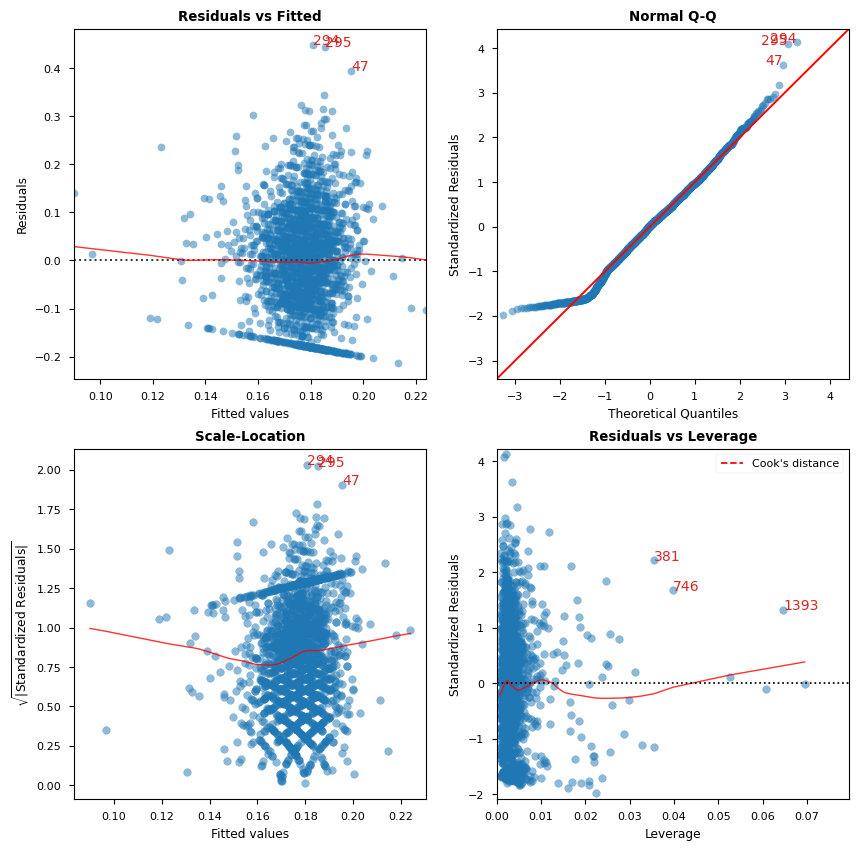

                          Features  VIF Factor
3  first_order_diff_Revenue_lagged        1.00
6                             Time        1.02
1                   Temp_No_Season        1.15
4                             tavg        1.37
2                   Rain_No_Season        2.08
5                              ppt        2.27
0                        intercept       11.65


In [18]:
from utils.Lin_reg_plotting import LinearRegDiagnostic
 
cls = LinearRegDiagnostic(results)

vif, fig, ax = cls()
print(vif)

From this model we see that nether rain nor temperature have a statiscally signifcant impact on our prediction of revenue

In [19]:
df_one_state_regression = df_one_state.copy()


x = df_one_state[["Temp_No_Season"]]
y = df_one_state["SMA7_ratio_cold_weather_clothing"]
model = sm.OLS(y, sm.add_constant(x))
results = model.fit()
#print(results.params)
print(results.summary())


                                   OLS Regression Results                                   
Dep. Variable:     SMA7_ratio_cold_weather_clothing   R-squared:                       0.000
Model:                                          OLS   Adj. R-squared:                 -0.000
Method:                               Least Squares   F-statistic:                    0.5917
Date:                              Wed, 05 Feb 2025   Prob (F-statistic):              0.442
Time:                                      17:07:31   Log-Likelihood:                 2706.5
No. Observations:                              1905   AIC:                            -5409.
Df Residuals:                                  1903   BIC:                            -5398.
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                     coef    std err          t      P>|t|      [0.025

In [20]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_one_state_plot = df_one_state.copy()
df_one_state_plot = df_one_state_plot.reset_index()
#df_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)


# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add temperature line
fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["tavg"],
        name="Averrage Temp",
        line=dict(color="red")
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["Temp_No_Season"],
        name="Temp_No_Season",
        line=dict(color="green")
    ),
    secondary_y=False
)


# Add revenue line
fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["SMA7_ratio_hot_weather_clothing"].shift(39),
        name="SMA7 Ratio hot weather clothing",
        line=dict(color="blue")
    ),
    secondary_y=True
)

fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["SMA7_ratio_cold_weather_clothing"].shift(39),
        name="SMA7 Ratio cold weather clothing",
        line=dict(color="yellow")
    ),
    secondary_y=True
)

# Update layout
fig.update_layout(
    title="Temperature and Revenue Change Over Time",
    xaxis_title="Order Date",
    width=1200,
    height=600
)

# Update y-axes labels
#fig.update_yaxes(title_text="Temperature", secondary_y=False)
#fig.update_yaxes(title_text="Revenue Change", secondary_y=True)

# Show the plot
fig.show()

c:\Users\morit\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

